In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = {
    "Area": [1000,1200,1500,1800,2000,2200,2500,3000],
    "Bedrooms": [2,2,3,3,4,4,4,5],
    "Age": [10,8,7,6,5,4,3,2],
    "Price": [35,40,50,60,70,75,85,100]
}
df = pd.DataFrame(data)

In [3]:
print("Shape is :",df.shape)
print(df.info())
print(df.describe())

Shape is : (8, 4)
<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Area      8 non-null      int64
 1   Bedrooms  8 non-null      int64
 2   Age       8 non-null      int64
 3   Price     8 non-null      int64
dtypes: int64(4)
memory usage: 388.0 bytes
None
              Area  Bedrooms       Age       Price
count     8.000000   8.00000   8.00000    8.000000
mean   1900.000000   3.37500   5.62500   64.375000
std     669.754753   1.06066   2.66927   22.430448
min    1000.000000   2.00000   2.00000   35.000000
25%    1425.000000   2.75000   3.75000   47.500000
50%    1900.000000   3.50000   5.50000   65.000000
75%    2275.000000   4.00000   7.25000   77.500000
max    3000.000000   5.00000  10.00000  100.000000


In [4]:
X = df[["Area","Bedrooms","Age"]]
y = df["Price"]

In [5]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [6]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.03, 2.12,-0.37]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Area','Bedrooms','Age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.044
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [7]:
y_pred = model.predict(X_test)

In [8]:
mae = mean_absolute_error(y_test,y_pred)
print(mae)

0.338427947597868


In [9]:
mse = mean_squared_error(y_test,y_pred)
print(mse)

0.2014168303422903


In [10]:
rmse = np.sqrt(mse)
print(rmse)

0.44879486443395306


In [11]:
r2 = r2_score(y_test,y_pred)
print(r2)

0.999342312390719


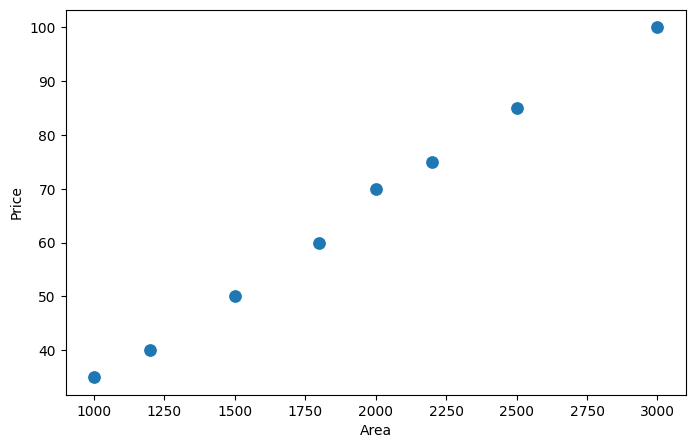

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="Area",
    y="Price",
    data=df,
    s=100
)
plt.show()

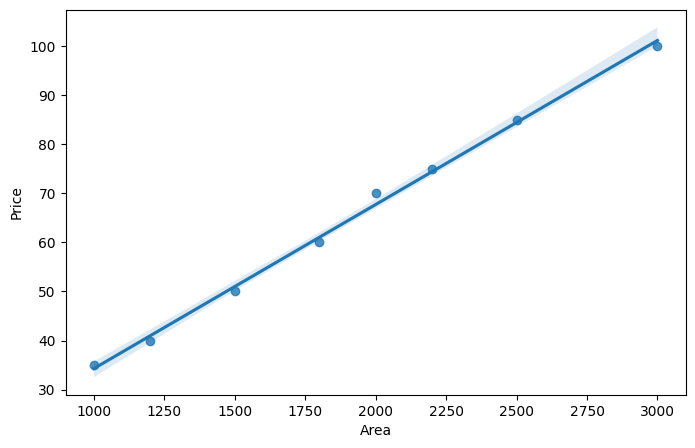

In [13]:
plt.figure(figsize=(8,5))
sns.regplot(
    x="Area",
    y="Price",
    data=df
)
plt.show()

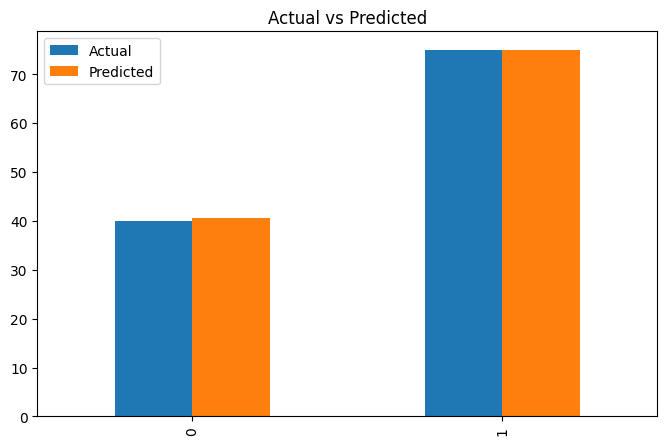

In [14]:
comparison = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":y_pred
})
comparison.plot(
    kind="bar",
    figsize=(8,5)
)
plt.title("Actual vs Predicted")
plt.show()

In [15]:
print("Business Questions\n")
print("\nWhich house is the most expensive?")
print(df.loc[df["Price"].idxmax()])
print("\nDoes area affect price?")
print(df[["Area","Price"]].corr())
print("\nDoes age affect price?")
print(df[["Age","Price"]].corr())
print("\n Predicted New House Price")
new_house = pd.DataFrame({
    "Area":[2100],
    "Bedrooms":[4],
    "Age":[4]
})

prediction = model.predict(new_house)

print("Predicted Price =", prediction[0])

Business Questions


Which house is the most expensive?
Area        3000
Bedrooms       5
Age            2
Price        100
Name: 7, dtype: int64

Does area affect price?
           Area     Price
Area   1.000000  0.998476
Price  0.998476  1.000000

Does age affect price?
            Age     Price
Age    1.000000 -0.982736
Price -0.982736  1.000000

 Predicted New House Price
Predicted Price = 72.09606986899573
